In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters
from skimage.io import imread
from skimage.feature import corner_peaks
from preprocessing import *
from solver import solve_sudoku, display_board, is_valid_sudoku

In [2]:
def display_image_grayscale(image, title="Image"):
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_image_color(image, title="Image"):
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

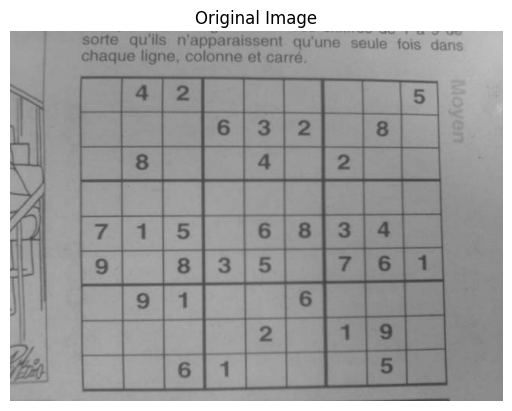

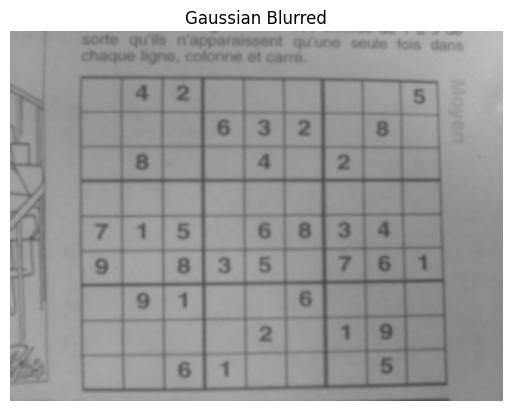

In [3]:
image = cv2.imread("images/image10.jpg", cv2.IMREAD_GRAYSCALE)
L = 5
box_kernel = np.ones((L, L)) / (L**2)
gaussian_kernel = create_gaussian_kernel(9)

blurred_image = linear_filter(image, box_kernel)
median_filter_image = median_filter(image, L)
gaussian_image = linear_filter(image, gaussian_kernel)

display_image_grayscale(image, "Original Image")
display_image_grayscale(gaussian_image, "Gaussian Blurred")

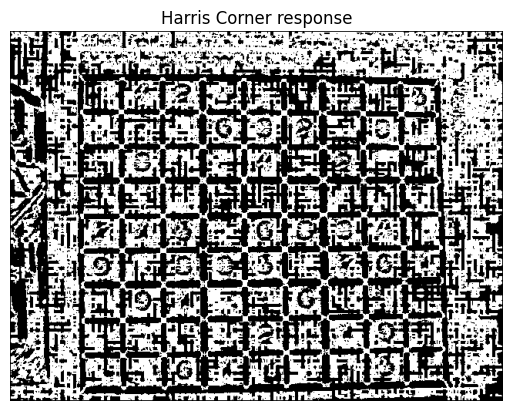

In [4]:
# Compute Harris corner response
response = harris_corners(image)
display_image_grayscale(response, "Harris Corner response")

Text(0.5, 1.0, 'Detected Corners')

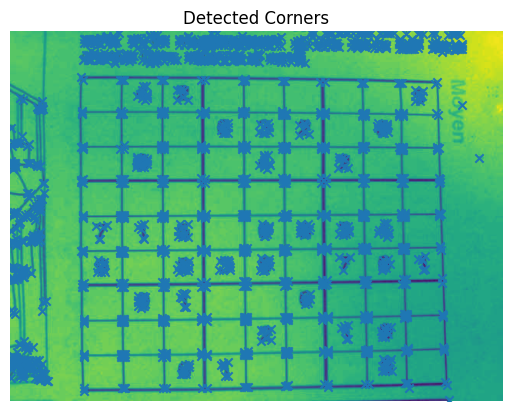

In [5]:
corners = corner_peaks(response, threshold_rel=0.01)

# Display detected corners
plt.imshow(image)
plt.scatter(corners[:,1], corners[:,0], marker='x')
plt.axis('off')
plt.title('Detected Corners')

In [6]:
sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

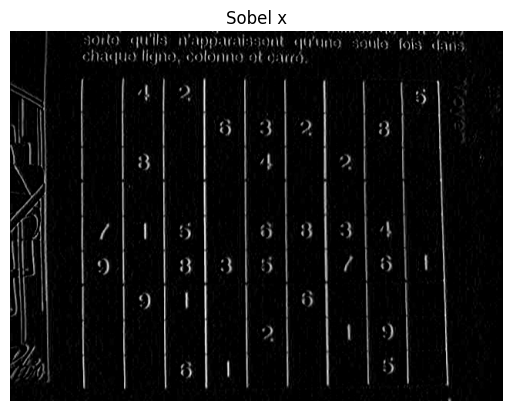

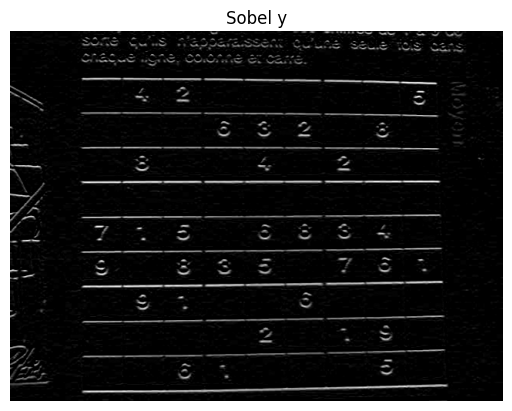

In [7]:
image_sobel_x = linear_filter(image, sobel_x_kernel)
image_sobel_y = linear_filter(image, sobel_y_kernel)
display_image_grayscale(image_sobel_x, "Sobel x")
display_image_grayscale(image_sobel_y, "Sobel y")

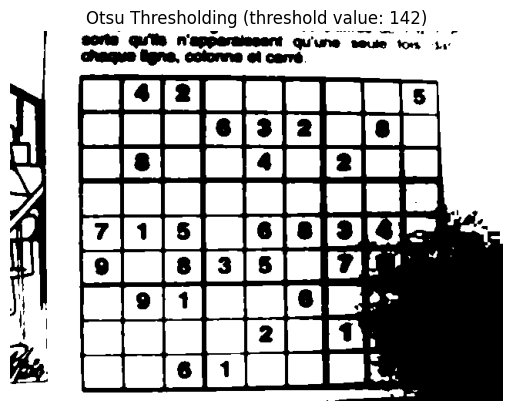

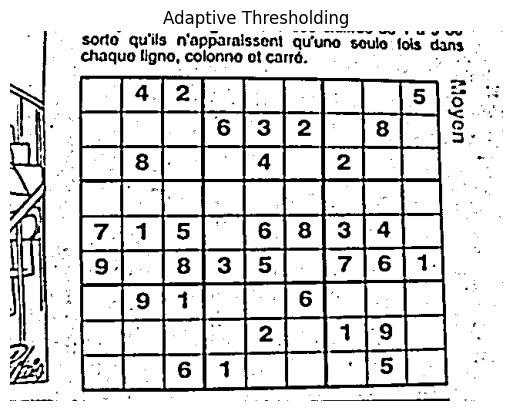

In [8]:
(hist, bin) = create_histogram(gaussian_image, 256, is_normalized=False)
threshold_val = find_otsu_threshold(hist)
image_thresh = perform_global_threshold(gaussian_image, threshold_val)
display_image_grayscale(image_thresh, f"Otsu Thresholding (threshold value: {threshold_val})")
display_image_grayscale(apply_adaptive_threshold(gaussian_image, 11, 1), "Adaptive Thresholding")

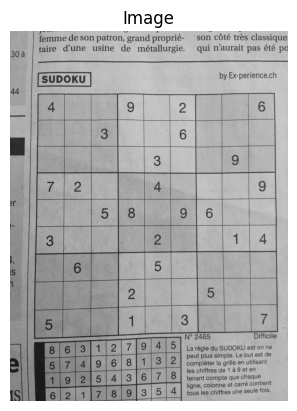

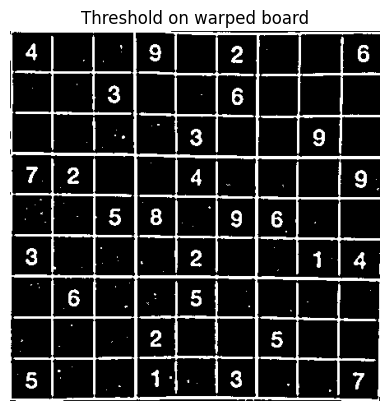

Successfully extracted 81 cells!


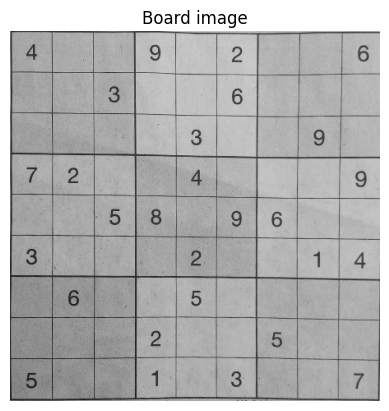

Are the cells empty?

False	True	True	False	True	False	True	True	False	
True	True	False	True	True	False	True	True	True	
True	True	True	True	False	True	True	False	True	
False	False	True	True	False	True	True	True	False	
True	True	False	False	True	False	False	True	True	
False	True	True	True	False	True	True	False	False	
True	False	True	True	False	True	True	True	True	
True	True	True	False	True	True	False	True	True	
False	True	True	False	True	False	True	True	False	

In [9]:
def extract_sudoku_cells(image_path):
    # Read the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    display_image_grayscale(img)
    if img is None:
        raise ValueError("Image not found. Check the path.")
    
    original = img.copy()

    # Pre-process: Blur and Adaptive Thresholding
    # Gaussian blur reduces high-frequency noise
    gaussian_kernel = create_gaussian_kernel(9, 1.6)
    blurred = linear_filter(img, gaussian_kernel, is_clipped=True)

    # Thresholding
    thresh = apply_adaptive_threshold(blurred, 11, 2, is_inverse=True)

    # Find contours (I don't think we can build custom version)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Suzuki Abe algorithm

    # Assume the Sudoku board is the largest contour by area
    # largest_contour = max(contours, key=cv2.contourArea) # replace this with find_area function

    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    grid_contour = None
    for contour in contours[:5]:
        contour = contour[:,0,:]
        perimeter = find_arc_length(contour, is_closed=True)
        epsilon = 0.02 * perimeter
        approx = approximate_polygon(contour, epsilon, is_closed=True)
        if len(approx) == 4:
            grid_contour = approx
            break

    if grid_contour is None:
        raise ValueError("Could not find 4 corners of the Sudoku board. Try better lighting.")


    # Perspective Transform (Flatten the board)
    rect = order_points(grid_contour)
    
    # Create a perfect square image to map the board to (450x450 is easily divisible by 9)
    side_length = 450
    dst = np.array([
        [0, 0],
        [side_length - 1, 0],
        [side_length - 1, side_length - 1],
        [0, side_length - 1]
    ], dtype="float32")

    # Calculate the homography matrix and apply it
    matrix = cv2.getPerspectiveTransform(rect, dst)
    warped_board = cv2.warpPerspective(original, matrix, (side_length, side_length))

    # Blur and apply threshold again but on the warped board this time. Used for determining if cell is empty.
    blurred_warped_board = linear_filter(warped_board, gaussian_kernel, is_clipped=True)
    thresh_warped_board = apply_adaptive_threshold(blurred_warped_board, 11, 2, is_inverse=True)
    display_image_grayscale(thresh_warped_board, "Threshold on warped board")

    # Divide the board into 81 cells
    cells = []
    cell_size = side_length // 9
    
    for i in range(9): # Rows
        for j in range(9): # Columns
            y_start = i * cell_size
            y_end = (i + 1) * cell_size
            x_start = j * cell_size
            x_end = (j + 1) * cell_size
            
            # Extract the cell
            cell = warped_board[y_start:y_end, x_start:x_end]
            
            # Optional but recommended: Crop the inner margins slightly 
            # to remove the thick grid lines before feeding to a classifier
            margin = int(cell_size * 0.1) # 10% crop on all sides
            cell_cropped = cell[margin:-margin, margin:-margin]
            isEmpty = is_cell_empty(thresh_warped_board[y_start:y_end, x_start:x_end], threshold_percent=0.07)
            
            cells.append((cell_cropped, isEmpty))

    return warped_board, cells

# --- Execution ---
if __name__ == "__main__":
    # Replace with image path
    image_path = "data/sudoku_dataset/images/image1086.jpg" 
    try:
        board_img, sudoku_cells = extract_sudoku_cells(image_path)
        print(f"Successfully extracted {len(sudoku_cells)} cells!")
        
        # Test display two of the 81 cells
        display_image_grayscale(board_img, "Board image")
        print("Are the cells empty?")
        for i in range(81):
            if i % 9 == 0:
                print("")
            print(f"{sudoku_cells[i][1]}", end="\t")
        
    except Exception as e:
        print(f"Error: {e}")

## Digit Recognition

Load the trained SVM model and classify each non-empty cell extracted above.

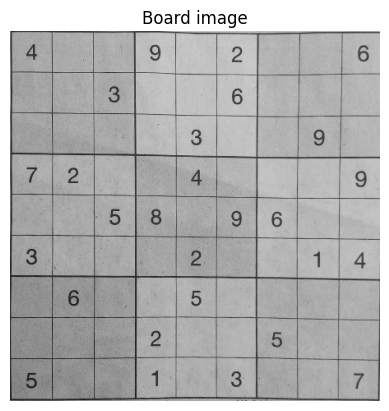

Recognized board:
4 . . | 9 . 2 | . . 6 
. . 3 | . . 6 | . . . 
. . . | . 3 . | . 9 . 
------+-------+------
7 2 . | . 4 . | . . 9 
. . 5 | 8 . 9 | 6 . . 
3 . . | . 2 . | . 1 4 
------+-------+------
. 6 . | . 5 . | . . . 
. . . | 2 . . | 5 . . 
5 . . | 1 . 3 | . . 7 


In [12]:
import joblib

from utils import normalize_cell, HOG_PARAMS, extract_features

model = joblib.load("models/digit_model.pkl")

def recognize_digits(cells):
    board = []
    for i in range(9):
        row = []
        for j in range(9):
            cell_img, is_empty = cells[i * 9 + j]
            if is_empty:
                row.append(".")
            else:
                cell_normalized = normalize_cell(cell_img)
                features = extract_features([cell_normalized])
                digit = model.predict(features)[0]
                row.append(str(digit))
        board.append(row)
    return board

display_image_grayscale(board_img, "Board image")
board = recognize_digits(sudoku_cells)
print("Recognized board:")
display_board(board)

In [13]:
if is_valid_sudoku(board):
    solve_sudoku(board)
    print()
    print("Solved board:")
    display_board(board)
else:
    print("Invalid board — digit recognition may have errors or the board is impossible to solve.")



Solved board:
4 5 8 | 9 1 2 | 3 7 6 
9 7 3 | 4 8 6 | 1 2 5 
6 1 2 | 5 3 7 | 4 9 8 
------+-------+------
7 2 6 | 3 4 1 | 8 5 9 
1 4 5 | 8 7 9 | 6 3 2 
3 8 9 | 6 2 5 | 7 1 4 
------+-------+------
2 6 1 | 7 5 8 | 9 4 3 
8 3 7 | 2 9 4 | 5 6 1 
5 9 4 | 1 6 3 | 2 8 7 
